# Apple Pricing — Predictive Modeling: Ridge vs KNN

**Business problem:** suggest a fair market price to sellers listing Apple products on Amazon/Flipkart (see `README.md` / `Apple_Pricing_EDA.ipynb`).

**Target:** `Current_Price_USD` (raw price, per modeling decision).

**Design locked in from the EDA phase:**

| Decision | Choice |
|---|---|
| Split | Time-based: train < 2025-08-01, test ≥ 2025-08-01 |
| Evaluation slices | A: time-test · C: iPhone 17 in test window (day-one launch, unseen new-model case) |
| Features | `Launch_Price_USD`, `days_since_launch`, `Product_Category`, `Condition`, `Sale_Event`, `month`, `Platform`, `Stock_Status` |
| Leakage columns | `Current_Price_INR`, `Discount_Pct`, `Launch_Price_INR` dropped at load |
| Ridge | mandatory category interactions, month one-hot, scaled numerics, alpha tuned via `TimeSeriesSplit` |
| KNN | StandardScaler, k ∈ {3, 5, 10, 20, 40, 80} × weights {uniform, distance}, `TimeSeriesSplit` |
| Metrics | RMSE, MAE, R² per slice, vs a naive group-mean baseline |

> Note: with raw USD as target, I expected `Launch_Price_USD` to dominate. To address this, StandardSclar is used for Ridge and KNN.

## 1. Load and prepare

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RNG = 42

TARGET = 'Current_Price_USD'
LEAK_COLS = ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']

df = pd.read_csv('apple_products_pricing_2020_2026.csv', parse_dates=['Date'])
df = df.drop(columns=LEAK_COLS)

# Feature engineering (same logic as the EDA notebook)
df['Sale_Event'] = df['Sale_Event'].fillna('None')
launch_date = df.groupby('Model_Name')['Date'].transform('min')  # metadata: model launch = first listing
df['days_since_launch'] = (df['Date'] - launch_date).dt.days
df['month'] = df['Date'].dt.month.astype(str)  # string -> guarantees categorical (12 dummies)

# variant_tier: NOT a model feature — kept only for the residual diagnostic at the end
TIERS = ['Pro Max', 'Ultra', 'Pro', 'Plus', 'Max', 'Air', 'mini', 'SE']
df['variant_tier'] = df['Model_Name'].map(lambda n: next((t for t in TIERS if t in n), 'base'))

print(f"{df.shape[0]:,} rows | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head(3)

80,000 rows | 2020-09-19 to 2026-07-31


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Sale_Event,Stock_Status,Rating,Reviews_Count,days_since_launch,month,variant_tier
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,435.81,None,In Stock,4.7,40,0,9,base
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,436.49,None,Out of Stock,4.6,84,1,9,base
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,None,In Stock,4.4,110,4,9,base


### Mandatory interactions (category-specific decay and price slopes)

A linear model cannot express "each category depreciates at its own rate" without explicit
`Product_Category × days_since_launch` (and `× Launch_Price_USD`) terms. These are deterministic
column constructions (not fitted statistics), so building them before the pipeline is leakage-safe.
Ridge's shrinkage handles the collinearity between the base columns and their interaction splits.

In [37]:
CATEGORIES = sorted(df['Product_Category'].unique())
INTERACTIONS = []
for c in CATEGORIES:
    ind = df['Product_Category'].eq(c).astype(int)
    df[f'days_x_{c}'] = df['days_since_launch'] * ind
    df[f'launch_x_{c}'] = df['Launch_Price_USD'] * ind
    INTERACTIONS += [f'days_x_{c}', f'launch_x_{c}']

NUM_FEATS = ['Launch_Price_USD', 'days_since_launch'] + INTERACTIONS
CAT_FEATS = ['Product_Category', 'Condition', 'Sale_Event', 'month', 'Platform', 'Stock_Status']
FEATS = NUM_FEATS + CAT_FEATS
print(f"{len(NUM_FEATS)} numeric features (incl. {len(INTERACTIONS)} interactions) + {len(CAT_FEATS)} categoricals")
print(INTERACTIONS)
df.head(3)

10 numeric features (incl. 8 interactions) + 6 categoricals
['days_x_Mac', 'launch_x_Mac', 'days_x_Watch', 'launch_x_Watch', 'days_x_iPad', 'launch_x_iPad', 'days_x_iPhone', 'launch_x_iPhone']


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Sale_Event,Stock_Status,Rating,Reviews_Count,days_since_launch,month,variant_tier,days_x_Mac,launch_x_Mac,days_x_Watch,launch_x_Watch,days_x_iPad,launch_x_iPad,days_x_iPhone,launch_x_iPhone
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,435.81,None,In Stock,4.7,40,0,9,base,0,0,0,429,0,0,0,0
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,436.49,None,Out of Stock,4.6,84,1,9,base,0,0,1,429,0,0,0,0
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,None,In Stock,4.4,110,4,9,base,0,0,4,429,0,0,0,0


## 2. Split — time cutoff (train/test)

Simple time-based split:

- **Train:** all rows before 2025-08-01.
- **Slice A (time-test):** all rows on/after 2025-08-01 — expected production accuracy.
- **Slice C (day-one launches):** iPhone 17 rows within slice A — a subset of A used to check
  performance on a brand-new model, since iPhone 17 only launches inside the test window and is
  therefore absent from train by construction (no separate holdout needed).

`TimeSeriesSplit` requires chronologically ordered training data — sorted below and kept sorted.

In [38]:
CUTOFF = pd.Timestamp('2025-08-01')

df = df.sort_values('Date').reset_index(drop=True)

train      = df[df['Date'] < CUTOFF]
slice_A    = df[df['Date'] >= CUTOFF]                                 # time-test
slice_C    = slice_A[slice_A['Model_Name'].str.contains('iPhone 17')] # day-one launches (unseen new-model case)

assert len(slice_C) > 0, "iPhone 17 not found in slice A — check Model_Name filtering"
n = len(df)
print(f"Train:            {len(train):>7,} rows ({len(train)/n*100:.1f}%)  {train['Date'].min():%Y-%m} to {train['Date'].max():%Y-%m}")
print(f"Slice A (time):   {len(slice_A):>7,} rows ({len(slice_A)/n*100:.1f}%)  {slice_A['Date'].min():%Y-%m} to {slice_A['Date'].max():%Y-%m}")
print(f"Slice C (day-one):{len(slice_C):>7,} rows — iPhone 17 within slice A")

Train:             54,099 rows (67.6%)  2020-09 to 2025-07
Slice A (time):    25,901 rows (32.4%)  2025-08 to 2026-07
Slice C (day-one):  2,652 rows — iPhone 17 within slice A


## 3. Naive baseline -- performance benchmark

Per-`(Product_Category, Condition)` mean price from train, with a global-mean fallback.
Any model that can't beat this isn't learning depreciation dynamics.

In [39]:
baseline_map = train.groupby(['Product_Category', 'Condition'])[TARGET].mean()
global_mean = train[TARGET].mean()

def baseline_predict(X):
    idx = pd.MultiIndex.from_frame(X[['Product_Category', 'Condition']])
    return pd.Series(idx.map(baseline_map), index=X.index).fillna(global_mean).values

print(baseline_map.round(2).to_string())

Product_Category  Condition          
Mac               New                    1474.61
                  Renewed/Refurbished    1140.21
Watch             New                     448.13
                  Renewed/Refurbished     350.75
iPad              New                     611.51
                  Renewed/Refurbished     470.67
iPhone            New                     830.38
                  Renewed/Refurbished     644.30


## 4. Ridge regression — pipeline + time-aware alpha tuning

All preprocessing (scaler, encoder) fits on train only, inside the Pipeline. `OneHotEncoder(handle_unknown='ignore')`
doubles as the serving-time fallback for unseen categories (e.g., a future sale-event name).

In [40]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATS),
])

ridge_pipe = Pipeline([('pre', preprocessor), ('model', Ridge(random_state=RNG))])

tscv = TimeSeriesSplit(n_splits=5)
ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={'model__alpha': np.logspace(-2, 3, 12)},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
ridge_grid.fit(train[FEATS], train[TARGET])

print(f"Best alpha: {ridge_grid.best_params_['model__alpha']:.4g}")
print(f"CV RMSE (expanding-window): {-ridge_grid.best_score_:.2f} USD")

Best alpha: 5.337
CV RMSE (expanding-window): 65.79 USD


### Coefficient report (best alpha)

Coefficients are in standardized units for numeric features (thanks to `StandardScaler`
inside the pipeline), so magnitude is directly comparable across numeric features. One-hot
categorical coefficients are each relative to their encoder's implicit reference — compare
within a category group, not across groups or against numeric features.

The “16 features” are the preprocessed input columns; the Ridge model actually fits on 38 transformed columns.
- Base inputs: 2 numeric + 6 categorical = 8.
- Added category interactions: for each of 4 product categories, days_since_launch × category and Launch_Price_USD × category → 8 more numeric columns.
- Total: 10 numeric + 6 categorical fields = 16.

OneHotEncoder then expands the 6 categorical fields into 28 dummy columns:
- Product category: 4
- Condition: 2
- Sale event: 5
- Month: 12
- Platform: 2
- Stock status: 3

So Ridge receives 10 numeric + 28 one-hot = 38 coefficients/features.

Intercept: 653.65 USD

All 38 coefficients, ranked by |coefficient|:
                              feature        type  coefficient
                num__Launch_Price_USD     numeric       343.48
                    num__launch_x_Mac     numeric       137.80
                 cat__Sale_Event_None categorical       102.61
                   cat__Condition_New categorical        94.95
   cat__Condition_Renewed/Refurbished categorical       -94.95
                 num__launch_x_iPhone     numeric        85.28
               num__days_since_launch     numeric       -63.10
                   num__launch_x_iPad     numeric        51.52
     cat__Sale_Event_Big Billion Days categorical       -45.09
                  num__launch_x_Watch     numeric        37.81
                   num__days_x_iPhone     numeric       -34.47
                      num__days_x_Mac     numeric       -27.04
            cat__Sale_Event_Prime Day categorical       -23.99
cat__Sale_Event_Great Indian Festival categorical

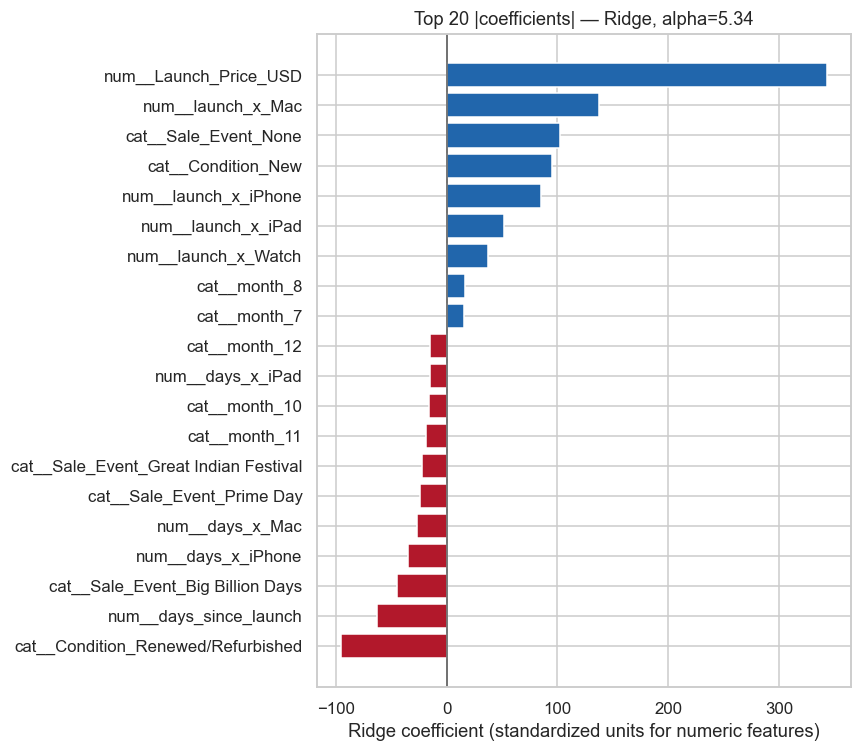

In [47]:
best_ridge = ridge_grid.best_estimator_
feature_names = best_ridge.named_steps['pre'].get_feature_names_out()
coefs = best_ridge.named_steps['model'].coef_
intercept = best_ridge.named_steps['model'].intercept_

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['type'] = np.where(coef_df['feature'].str.startswith('num__'), 'numeric', 'categorical')
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).drop(columns='abs_coefficient')
coef_df = coef_df[['feature', 'type', 'coefficient']]

print(f"Intercept: {intercept:.2f} USD")
print(f"\nAll {len(coef_df)} coefficients, ranked by |coefficient|:")
print(coef_df.round(2).to_string(index=False))

top = coef_df.head(20).sort_values('coefficient')
colors = ['#2166ac' if c >= 0 else '#b2182b' for c in top['coefficient']]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top['feature'], top['coefficient'], color=colors)
ax.axvline(0, color='#555555', lw=1)
ax.set(xlabel='Ridge coefficient (standardized units for numeric features)',
       title=f'Top 20 |coefficients| — Ridge, alpha={ridge_grid.best_params_["model__alpha"]:.3g}')
plt.tight_layout(); plt.show()


## 5. KNN — StandardScaler, k-search with `TimeSeriesSplit`

Random-fold CV would leak: a listing's nearest neighbor is usually the same model days earlier,
so tiny k looks spectacular under KFold and collapses out-of-time. The expanding-window CV below
gives honest k selection. (On the full 80k-row dataset this grid takes a few minutes.)

Best params: {'model__n_neighbors': 40, 'model__weights': 'distance'}
CV RMSE (expanding-window): 87.78 USD


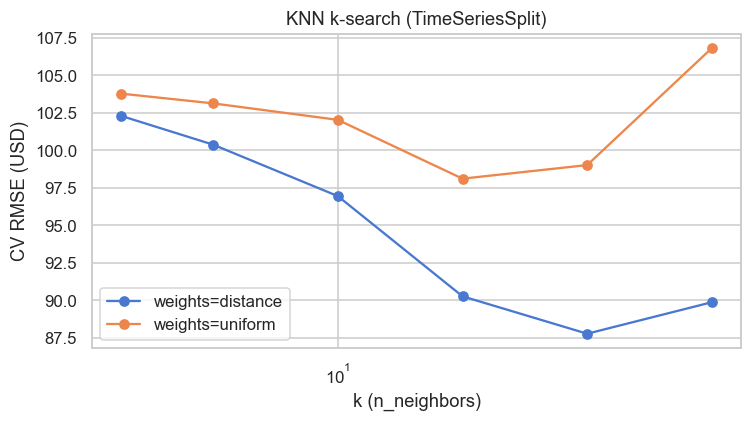

In [42]:
knn_pipe = Pipeline([('pre', preprocessor), ('model', KNeighborsRegressor())])

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid={'model__n_neighbors': [3, 5, 10, 20, 40, 80],
                'model__weights': ['uniform', 'distance']},
    cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1,
)
knn_grid.fit(train[FEATS], train[TARGET])

print(f"Best params: {knn_grid.best_params_}")
print(f"CV RMSE (expanding-window): {-knn_grid.best_score_:.2f} USD")

# k-search curve
cvres = pd.DataFrame(knn_grid.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
for w, g in cvres.groupby('param_model__weights'):
    g = g.sort_values('param_model__n_neighbors')
    ax.plot(g['param_model__n_neighbors'].astype(int), -g['mean_test_score'], marker='o', label=f'weights={w}')
ax.set(xlabel='k (n_neighbors)', ylabel='CV RMSE (USD)', title='KNN k-search (TimeSeriesSplit)')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Evaluation — Baseline vs Ridge vs KNN

In [43]:
def score(y_true, y_pred):
    return {'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

slices = {'A: time-test': slice_A, 'C: day-one (iPhone 17)': slice_C}
models = {'Baseline (group mean)': baseline_predict,
          'Ridge': lambda X: ridge_grid.predict(X[FEATS]),
          'KNN': lambda X: knn_grid.predict(X[FEATS])}

rows = []
for sname, s in slices.items():
    if len(s) == 0:
        continue
    for mname, predict in models.items():
        rows.append({'slice': sname, 'model': mname, 'n': len(s), **score(s[TARGET], predict(s))})

results = pd.DataFrame(rows).set_index(['slice', 'model']).round(3)
results

n     RMSE      MAE     R2
slice                  model                                                
A: time-test           Baseline (group mean)  25901  277.659  223.556  0.632
                       Ridge                  25901   74.917   53.389  0.973
                       KNN                    25901   60.894   40.135  0.982
C: day-one (iPhone 17) Baseline (group mean)   2652   41.424   29.726  0.792
                       Ridge                   2652   27.017   19.778  0.912
                       KNN                     2652   45.917   41.028  0.744

**How to read this:** slice A is expected production accuracy; slice C is the hardest case —
brand-new launches with near-zero `days_since_launch`, testing generalization to a model unseen
in training. R² on slice C is computed against within-slice variance (a single model), so it is
naturally lower — compare RMSE/MAE across models rather than R² across slices.

### Train vs test: overfitting check

Same metrics on the training set, to compare against slice A.

**Interpretation caveats:**
- **KNN train scores are perfect by construction, not by merit.** When predicting a training row, that
  row is its own nearest neighbor at distance 0, and with `weights='distance'` an exact match takes the
  entire weight — the model returns the row's own price. The honest "train-side" figure for KNN is its
  expanding-window **CV RMSE** (Section 5), not the in-sample score.
- **Ridge's train-vs-test gap is the meaningful one:** a small gap means the linear model is not
  overfitting; a large gap would suggest the interactions/dummies are memorizing training-era structure.
- The KNN row below also takes a while: predicting all ~53k training rows requires a full
  53k × 53k neighbor search.

In [44]:
rows_tt = []
for mname, predict in models.items():
    rows_tt.append({'set': 'train', 'model': mname, 'n': len(train), **score(train[TARGET], predict(train))})
    rows_tt.append({'set': 'test (slice A)', 'model': mname, 'n': len(slice_A), **score(slice_A[TARGET], predict(slice_A))})

tt = pd.DataFrame(rows_tt).set_index(['model', 'set']).round(3)
print("Reminder: KNN 'train' row is a self-neighbor artifact — use CV RMSE (Section 5) as its honest train-side score.")
tt

Reminder: KNN 'train' row is a self-neighbor artifact — use CV RMSE (Section 5) as its honest train-side score.


n     RMSE      MAE     R2
model                 set                                           
Baseline (group mean) train           54099  292.791  236.135  0.601
                      test (slice A)  25901  277.659  223.556  0.632
Ridge                 train           54099   63.058   45.204  0.981
                      test (slice A)  25901   74.917   53.389  0.973
KNN                   train           54099   10.062    3.639  1.000
                      test (slice A)  25901   60.894   40.135  0.982

## 7. Listing-time sensitivity: `Stock_Status` defaulted to "In Stock"

A seller's brand-new listing has no stock status yet; at serving it will be fixed to `"In Stock"`.
This re-scores slice C (day-one iPhone 17 launches) under that deployment condition to measure
the train/serve mismatch.

In [45]:
C_serving = slice_C.copy()
C_serving['Stock_Status'] = 'In Stock'

cmp = pd.DataFrame({
    'as-recorded': {m: score(slice_C[TARGET], f(slice_C))['RMSE'] for m, f in models.items()},
    'Stock_Status="In Stock"': {m: score(C_serving[TARGET], f(C_serving))['RMSE'] for m, f in models.items()},
}).round(3)
cmp.index.name = 'RMSE on slice C'
print(cmp.to_string())
print("\nSmall delta -> the listing-time default is safe; large delta -> consider dropping Stock_Status.")

                       as-recorded  Stock_Status="In Stock"
RMSE on slice C                                            
Baseline (group mean)       41.424                   41.424
Ridge                       27.017                   27.046
KNN                         45.917                   49.153

Small delta -> the listing-time default is safe; large delta -> consider dropping Stock_Status.


## 8. Residual diagnostic: is the "premiums are priced in" assumption holding?

`variant_tier` is deliberately **not** a feature. If residuals grouped by tier are centered near zero,
`Launch_Price_USD` + `Product_Category` has absorbed the tier premiums as assumed. A tier with
systematically one-sided residuals (e.g., Pro Max under-predicted) means the assumption leaks and
tier deserves promotion to a feature.

Best model on slice A: KNN


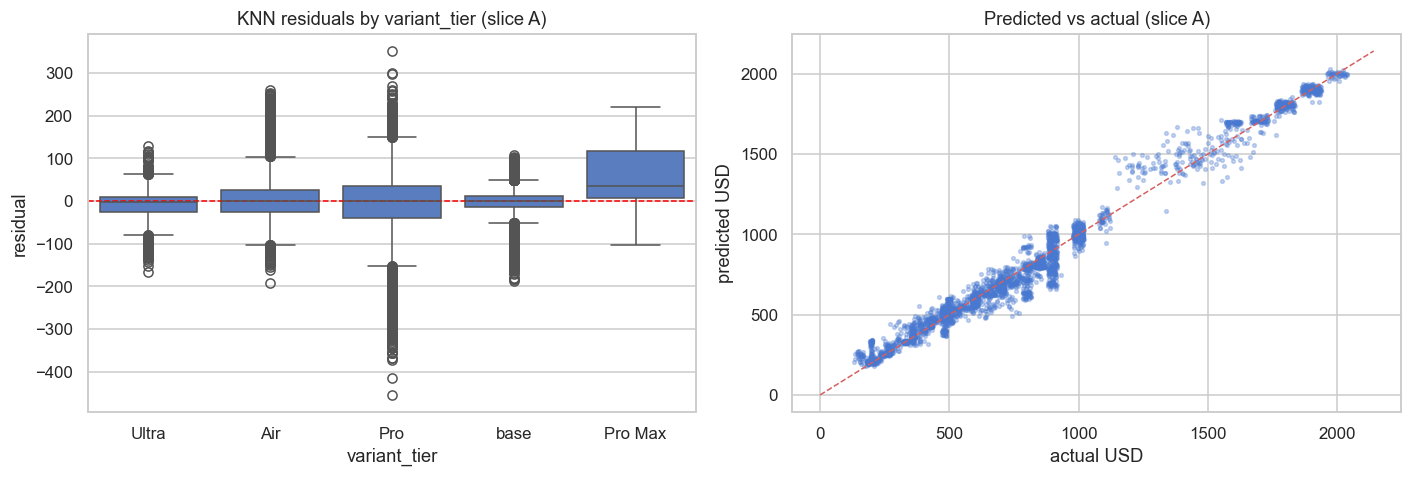

              count   mean  median
variant_tier                      
Air            3246  14.41   -1.19
Pro            8673  -6.00   -1.13
Pro Max        1381  59.90   34.97
Ultra          1543 -10.13   -2.52
base          11058  -2.77   -0.47

Mean residual > 0 = under-prediction. One-sided tiers -> 'priced-in' assumption leaks there.


In [46]:
best_name = results.xs('A: time-test')['RMSE'].drop('Baseline (group mean)').idxmin()
best_fn = models[best_name]
print(f"Best model on slice A: {best_name}")

diag = slice_A.copy()
diag['residual'] = diag[TARGET] - best_fn(diag)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = diag.groupby('variant_tier')['residual'].median().sort_values().index
sns.boxplot(data=diag, x='variant_tier', y='residual', order=order, ax=axes[0])
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_title(f'{best_name} residuals by variant_tier (slice A)')

sample = diag.sample(min(4000, len(diag)), random_state=RNG)
axes[1].scatter(sample[TARGET], sample[TARGET] - sample['residual'], s=6, alpha=.3)
lims = [0, diag[TARGET].max() * 1.05]
axes[1].plot(lims, lims, 'r--', lw=1)
axes[1].set(xlabel='actual USD', ylabel='predicted USD', title='Predicted vs actual (slice A)')
plt.tight_layout(); plt.show()

tier_tbl = diag.groupby('variant_tier')['residual'].agg(['count', 'mean', 'median']).round(2)
print(tier_tbl.to_string())
print("\nMean residual > 0 = under-prediction. One-sided tiers -> 'priced-in' assumption leaks there.")

## 9. Conclusions (fill in after running on the real data)

- **Model choice:** compare Ridge vs KNN on slice A (production accuracy), but weight slice C
  heavily — the seller tool lives or dies on new-model pricing. Check whether KNN's slice-C error
  degrades more than Ridge's, since a brand-new model's neighbors are dominated by other models'
  listings.
- **Baseline check:** if either model fails to clearly beat the group-mean baseline on slice A, features
  (not model choice) are the bottleneck.
- **Next steps:** if variant-tier residuals are one-sided, promote `variant_tier` (with an 'unknown'
  fallback level). If scale-dependent residuals appear in the predicted-vs-actual plot, retry with a
  log-price target. Add quantile intervals (e.g., quantile gradient boosting) before shipping the
  seller-facing suggestion.